<a href="https://colab.research.google.com/github/Sujan279/ML/blob/main/LAB2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google .colab import files
uploaded = files.upload()

Saving housing.csv to housing (1).csv


In [4]:
# Display the first 10 rows and data types of all attributes.
import pandas as pd
df= pd.read_csv('housing.csv')
print(df.head(10))

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   
5    -122.25     37.85                52.0        919.0           213.0   
6    -122.25     37.84                52.0       2535.0           489.0   
7    -122.25     37.84                52.0       3104.0           687.0   
8    -122.26     37.84                42.0       2555.0           665.0   
9    -122.25     37.84                52.0       3549.0           707.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0   

In [5]:
'''Compute basic statistics (mean, median, std, min, max) for numeric
attributes.'''

df.describe()
df.select_dtypes(include='number').agg(
    ['mean', 'median', 'std', 'min', 'max']
)
numeric_df = df.select_dtypes(include='number')

numeric_df.mean()
numeric_df.median()
numeric_df.std()
numeric_df.min()
numeric_df.max()


,0
longitude,-114.3100
latitude,41.9500
housing_median_age,52.0000
total_rooms,39320.0000
total_bedrooms,6445.0000
population,35682.0000
households,6082.0000
median_income,15.0001
median_house_value,500001.0000


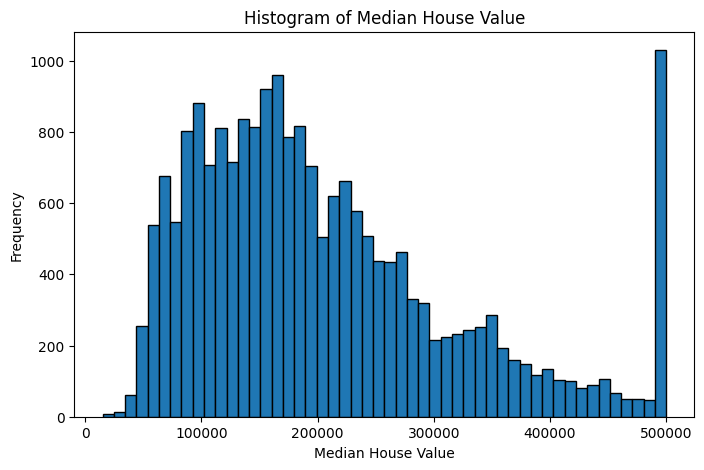

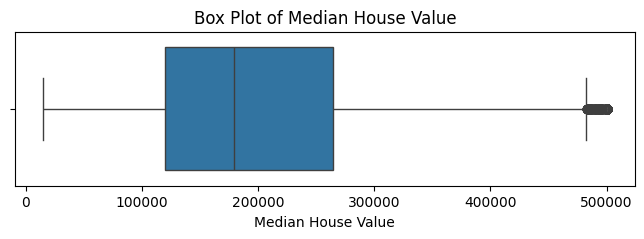

In [6]:
'''Examine the distribution of the target variable (median_house_value)
using a histogram and box plot.'''

import matplotlib.pyplot as plt
import seaborn as sns

# Histogram
plt.figure(figsize=(8, 5))
plt.hist(df['median_house_value'], bins=50, edgecolor='black')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.title('Histogram of Median House Value')
plt.show()

# Box plot
plt.figure(figsize=(8, 2))
sns.boxplot(x=df['median_house_value'])
plt.xlabel('Median House Value')
plt.title('Box Plot of Median House Value')
plt.show()


In [7]:
'''Identify any missing data values and list the percentage of missing
values per column.'''

import pandas as pd

missing_data = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
})

missing_data
missing_data[missing_data['Missing Values'] > 0]
df.isnull().mean() * 100


,0
longitude,0.000000
latitude,0.000000
housing_median_age,0.000000
total_rooms,0.000000
total_bedrooms,1.002907
population,0.000000
households,0.000000
median_income,0.000000
median_house_value,0.000000
ocean_proximity,0.000000


In [17]:
'''Handle missing values in total_bedrooms using an appropriate
imputation strategy and justify your choice.'''


df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

df['total_bedrooms'].isnull().sum()

df[['total_bedrooms']].head(10)

df.head()




,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [18]:
'''Encode the categorical attribute ocean_proximity using one-hot
encoding.'''


df = pd.get_dummies(df, columns=['ocean_proximity'])
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False


In [20]:
#Perform feature scaling (MinMax scaler) on all numeric features.
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
numeric_cols = df.select_dtypes(include='number').columns

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.211155,0.567481,0.784314,0.022331,0.019863,0.008941,0.020556,0.539668,0.902266,False,False,False,True,False
1,0.212151,0.565356,0.392157,0.180503,0.171477,0.067210,0.186976,0.538027,0.708247,False,False,False,True,False
2,0.210159,0.564293,1.000000,0.037260,0.029330,0.013818,0.028943,0.466028,0.695051,False,False,False,True,False
3,0.209163,0.564293,1.000000,0.032352,0.036313,0.015555,0.035849,0.354699,0.672783,False,False,False,True,False
4,0.209163,0.564293,1.000000,0.041330,0.043296,0.015752,0.042427,0.230776,0.674638,False,False,False,True,False


In [21]:
#minmax_scaler = MinMaxScaler(feature_range=(0, 1)
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler(feature_range=(0, 1))

numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = minmax_scaler.fit_transform(df[numeric_cols])

df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.211155,0.567481,0.784314,0.022331,0.019863,0.008941,0.020556,0.539668,0.902266,False,False,False,True,False
1,0.212151,0.565356,0.392157,0.180503,0.171477,0.067210,0.186976,0.538027,0.708247,False,False,False,True,False
2,0.210159,0.564293,1.000000,0.037260,0.029330,0.013818,0.028943,0.466028,0.695051,False,False,False,True,False
3,0.209163,0.564293,1.000000,0.032352,0.036313,0.015555,0.035849,0.354699,0.672783,False,False,False,True,False
4,0.209163,0.564293,1.000000,0.041330,0.043296,0.015752,0.042427,0.230776,0.674638,False,False,False,True,False


In [27]:
'''Split the dataset into training (80%) and test (20%) sets using
stratified sampling on the median_income attribute.'''

from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np
import pandas as pd

original_df = pd.read_csv('housing.csv') # Reload to get unscaled data
original_median_income = original_df['median_income']


income_cat = pd.cut(original_median_income, bins=[0., 1.5, 3.0, 4.5, 6.0, np.inf], labels=[1, 2, 3, 4, 5])


df_original_income = df.copy()
df_original_income['income_cat'] = income_cat.values # Assign the series values

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(df_original_income, df_original_income['income_cat']):
    strat_train_set = df_original_income.iloc[train_index].copy()
    strat_test_set = df_original_income.iloc[test_index].copy()

strat_train_set = strat_train_set.drop('income_cat', axis=1)
strat_test_set = strat_test_set.drop('income_cat', axis=1)

strat_train_set.shape, strat_test_set.shape

((16512, 14), (4128, 14))

In [28]:
'''Construct the correlation matrix for all numerical attributes in the
California Housing dataset.'''

correlation_matrix = df.corr()
correlation_matrix


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,income_cat
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069120,0.099773,0.055310,-0.015176,-0.045967,0.321121,-0.055575,0.009446,-0.474489,0.045509,NaN
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066484,-0.108785,-0.071035,-0.079809,-0.144160,-0.446969,0.351166,-0.016572,0.358771,-0.160818,NaN
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.319026,-0.296244,-0.302916,-0.119034,0.105623,0.045300,-0.236645,0.017020,0.255172,0.021622,NaN
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.927058,0.857126,0.918484,0.198050,0.134153,-0.003031,0.025624,-0.007572,-0.023022,-0.009175,NaN
total_bedrooms,0.069120,-0.066484,-0.319026,0.927058,1.000000,0.873535,0.974366,-0.007617,0.049457,0.017966,-0.006158,-0.004322,-0.019667,0.000557,NaN
population,0.099773,-0.108785,-0.296244,0.857126,0.873535,1.000000,0.907222,0.004834,-0.024650,0.074613,-0.020732,-0.010412,-0.060880,-0.024264,NaN
households,0.055310,-0.071035,-0.302916,0.918484,0.974366,0.907222,1.000000,0.013033,0.065843,0.042435,-0.039402,-0.009077,-0.010093,0.001714,NaN
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007617,0.004834,0.013033,1.000000,0.688075,0.168876,-0.237496,-0.009228,0.056197,0.027344,NaN
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049457,-0.024650,0.065843,0.688075,1.000000,0.256617,-0.484859,0.023416,0.160284,0.141862,NaN
ocean_proximity_<1H OCEAN,0.321121,-0.446969,0.045300,-0.003031,0.017966,0.074613,0.042435,0.168876,0.256617,1.000000,-0.607669,-0.013872,-0.314813,-0.342620,NaN


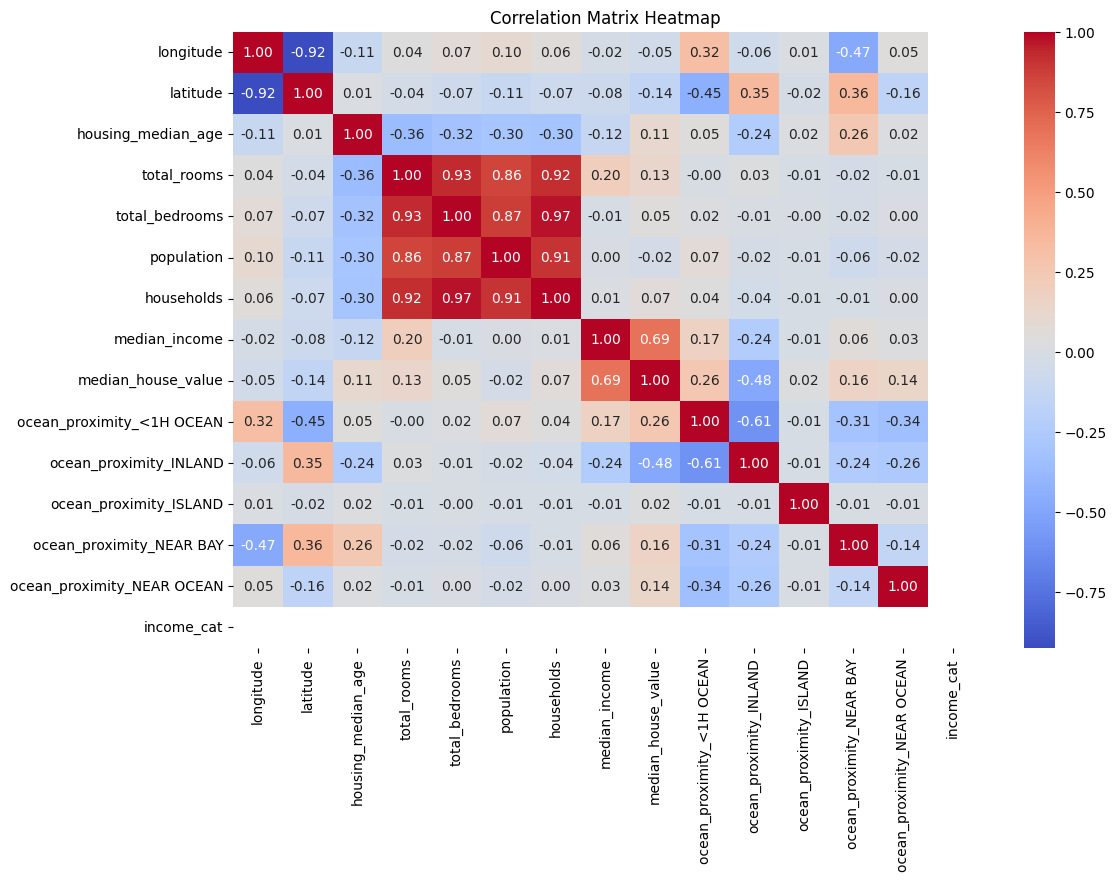

In [29]:
'''Visualize the correlation matrix using a heatmap and interpret the
results.'''

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix Heatmap")
plt.show()


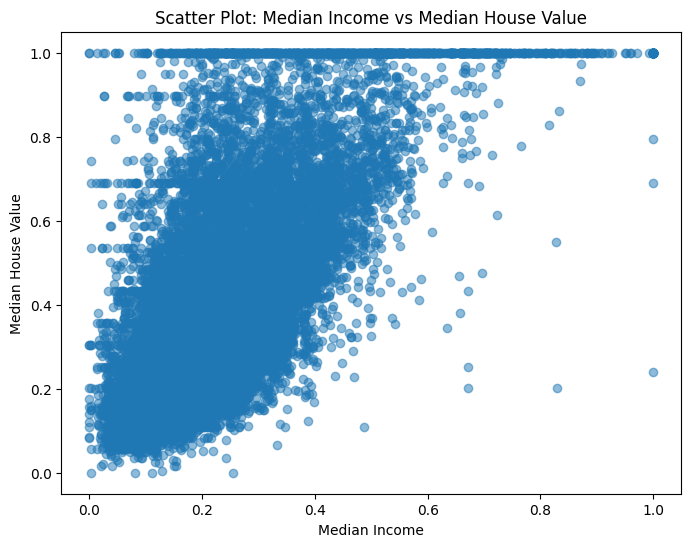

In [30]:
'''• Plot a scatter diagram between median_income and median_house_value.
a) What trend do you observe from the scatter plot?
b) Does the relationship appear linear or non-linear?
c) Identify any visible outliers or clusters.'''

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(df['median_income'], df['median_house_value'], alpha=0.5)
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Scatter Plot: Median Income vs Median House Value')
plt.show()


In [31]:
'''• Divide the dataset into 80% training and 20% testing sets using random
sampling.'''

from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

train_set.shape, test_set.shape


((16512, 15), (4128, 15))

In [32]:
'''• Identify:
• The top three features most positively correlated with
median_house_value'''

correlation_matrix = df.corr()
top_features = correlation_matrix['median_house_value'].sort_values(ascending=False)
top_features[1:4]


,median_house_value
median_income,0.688075
ocean_proximity_<1H OCEAN,0.256617
ocean_proximity_NEAR BAY,0.160284


In [33]:
 # The most negatively correlated feature
 correlation_matrix = df.corr()
most_negative_feature = correlation_matrix['median_house_value'].sort_values().head(1)
most_negative_feature


,median_house_value
ocean_proximity_INLAND,-0.484859


In [34]:
#Apply Standard Scaling to all numerical features in the dataset.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,income_cat
0,-1.327835,1.052548,0.982143,-0.804819,-0.972476,-0.974429,-0.977033,2.344766,2.129631,False,False,False,True,False,1
1,-1.322844,1.043185,-0.607019,2.045890,1.357143,0.861439,1.669961,2.332238,1.314156,False,False,False,True,False,1
2,-1.332827,1.038503,1.856182,-0.535746,-0.827024,-0.820777,-0.843637,1.782699,1.258693,False,False,False,True,False,1
3,-1.337818,1.038503,1.856182,-0.624215,-0.719723,-0.766028,-0.733781,0.932968,1.165100,False,False,False,True,False,1
4,-1.337818,1.038503,1.856182,-0.462404,-0.612423,-0.759847,-0.629157,-0.012881,1.172900,False,False,False,True,False,1


In [35]:
#scaler = StandardScaler()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,income_cat
0,-1.327835,1.052548,0.982143,-0.804819,-0.972476,-0.974429,-0.977033,2.344766,2.129631,False,False,False,True,False,1
1,-1.322844,1.043185,-0.607019,2.045890,1.357143,0.861439,1.669961,2.332238,1.314156,False,False,False,True,False,1
2,-1.332827,1.038503,1.856182,-0.535746,-0.827024,-0.820777,-0.843637,1.782699,1.258693,False,False,False,True,False,1
3,-1.337818,1.038503,1.856182,-0.624215,-0.719723,-0.766028,-0.733781,0.932968,1.165100,False,False,False,True,False,1
4,-1.337818,1.038503,1.856182,-0.462404,-0.612423,-0.759847,-0.629157,-0.012881,1.172900,False,False,False,True,False,1


In [39]:
# Train the Linear Regression using the training data.

from sklearn.linear_model import LinearRegression

# Drop 'median_house_value' and 'income_cat' (if present) from the training features
# 'income_cat' was an auxiliary column for stratification and not a direct feature
# for the linear model.
X_train = train_set.drop(['median_house_value', 'income_cat'], axis=1, errors='ignore')
y_train = train_set['median_house_value']

model = LinearRegression()
model.fit(X_train, y_train)

model.coef_, model.intercept_

(array([-0.55557764, -0.4941365 ,  0.1158994 , -0.48814966,  1.36571574,
        -2.80817631,  0.60499748,  1.18016118, -0.03902372, -0.12105773,
         0.24164537, -0.04961469, -0.03194923]),
 np.float64(0.5316246634049122))

In [44]:
#Find the Root Mean Squared Error (RMSE)

from sklearn.metrics import mean_squared_error
import numpy as np

# Drop 'median_house_value' and 'income_cat' from the test features to match X_train
X_test = test_set.drop(['median_house_value', 'income_cat'], axis=1, errors='ignore')
y_test = test_set['median_house_value']

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse

np.float64(0.1444540885289858)

In [46]:
#Mean Absolute Error (MAE)
from sklearn.metrics import mean_absolute_error

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mae


0.10447531812440339

In [47]:
#R2 Score and display

from sklearn.metrics import r2_score

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
r2


0.6254240620553606